# Notebook 06 — HY vs IG inclusion-probability comparison

Loads the pickled BSTS artifacts from notebooks 04 (HY) and 05 (IG), produces:

1. **Side-by-side bar chart** of inclusion probabilities — the headline cross-target visualization
2. **Group-level summary** — sum of inclusion probs per OECD economic group
3. **Shared vs divergent table** — predictors important for both vs only one target

This is the chart for the presentation: it answers *"do the same Trends signals predict HY and IG, or do they differ?"*


In [1]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd().resolve()))
from _helpers import project_root_from_cwd
import pickle
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
project_root_from_cwd()

from gtrends_bayes.config import PredictorsConfig
from gtrends_bayes.features.groups import group_columns, GROUP_DESCRIPTIONS

In [2]:
hy = pickle.loads(Path('data/processed/posterior/HY_bsts_v1.pkl').read_bytes())
ig = pickle.loads(Path('data/processed/posterior/IG_bsts_v1.pkl').read_bytes())
print(f'HY: {len(hy["inclusion_probs"])} predictors')
print(f'IG: {len(ig["inclusion_probs"])} predictors')
# Build side-by-side DataFrame.
combined = pd.concat([
    hy['inclusion_probs'].rename('HY'),
    ig['inclusion_probs'].rename('IG'),
], axis=1).fillna(0).sort_values('HY', ascending=False)
combined.head(10)

HY: 24 predictors
IG: 24 predictors


,HY,IG
Economic crisis,1.000000,1.000000
vix,0.408148,0.022222
Bankruptcy,0.057037,0.014815
Foreclosure,0.020741,0.011111
Home Financing,0.020000,0.007407
Agriculture & Forestry,0.017778,0.034074
ust2y10y_slope,0.015556,0.015556
Apparel,0.014074,0.086667
Autos & Vehicles,0.013333,0.088889
Investing,0.009630,0.017778


## 1. Side-by-side bar chart

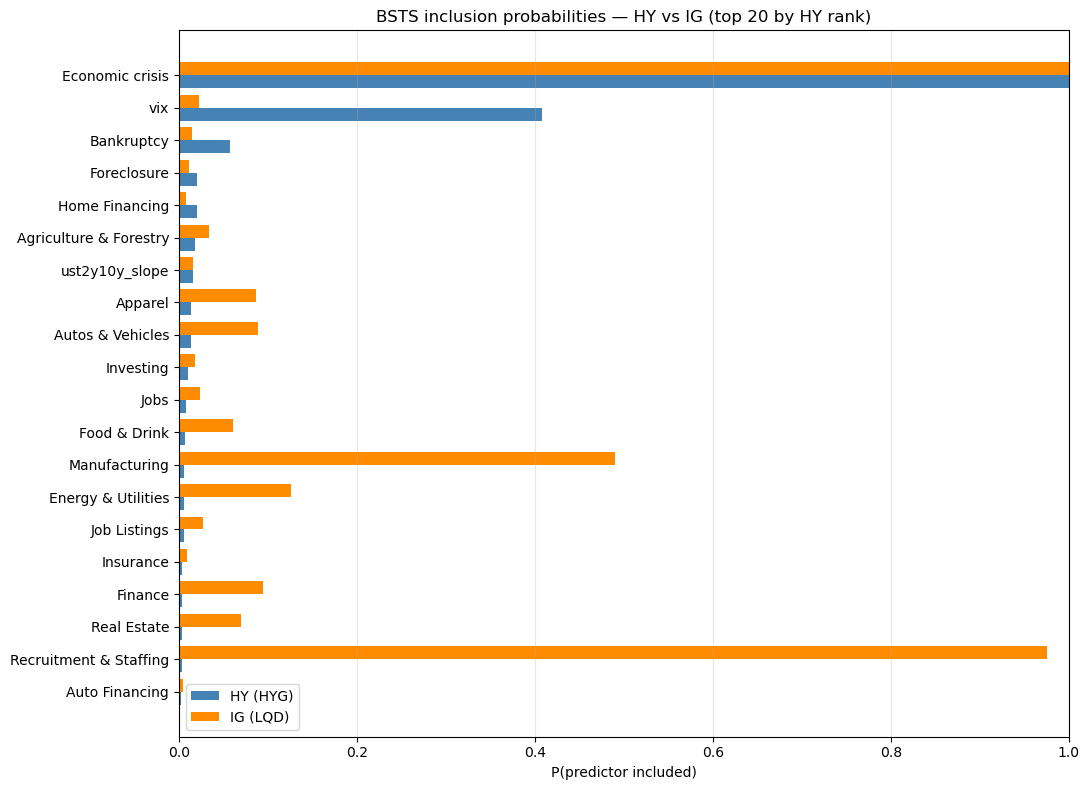

In [3]:
n_show = min(20, len(combined))
plot_df = combined.head(n_show).iloc[::-1]
fig, ax = plt.subplots(figsize=(11, 8))
yy = np.arange(len(plot_df))
bar_h = 0.4
ax.barh(yy - bar_h/2, plot_df['HY'].values, height=bar_h, color='steelblue', label='HY (HYG)')
ax.barh(yy + bar_h/2, plot_df['IG'].values, height=bar_h, color='darkorange', label='IG (LQD)')
ax.set_yticks(yy)
ax.set_yticklabels(plot_df.index)
ax.set_xlim(0, 1)
ax.set_xlabel('P(predictor included)')
ax.set_title(f'BSTS inclusion probabilities — HY vs IG (top {n_show} by HY rank)')
ax.legend()
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

## 2. Group-level summary

In [4]:
pred_cfg = PredictorsConfig.from_yaml('config/predictors.yaml')
parts = group_columns(combined.index, pred_cfg)
rows = []
for group, cols in sorted(parts.items()):
    rows.append({
        'group': group,
        'description': GROUP_DESCRIPTIONS.get(group, '(market controls / unmapped)'),
        'n_predictors': len(cols),
        'HY_total_incl_prob': combined.loc[cols, 'HY'].sum().round(3),
        'IG_total_incl_prob': combined.loc[cols, 'IG'].sum().round(3),
    })
group_df = pd.DataFrame(rows).sort_values('HY_total_incl_prob', ascending=False)
group_df

,group,description,n_predictors,HY_total_incl_prob,IG_total_incl_prob
3,crisis,Recession / crisis topics,1,1.000,1.000
0,_unmapped,(market controls / unmapped),3,0.426,1.038
4,distress,Bankruptcy + foreclosure categories,2,0.078,0.026
1,consumption,Consumer-spending categories,6,0.041,2.290
6,industrial,Industrial-activity categories,3,0.030,0.650
2,credit_lending,Consumer + commercial credit categories,3,0.024,0.018
5,finance_meta,"Generic finance categories (Investing, Insuran...",3,0.016,0.121
7,labor,Jobs / unemployment-related categories,3,0.016,1.025


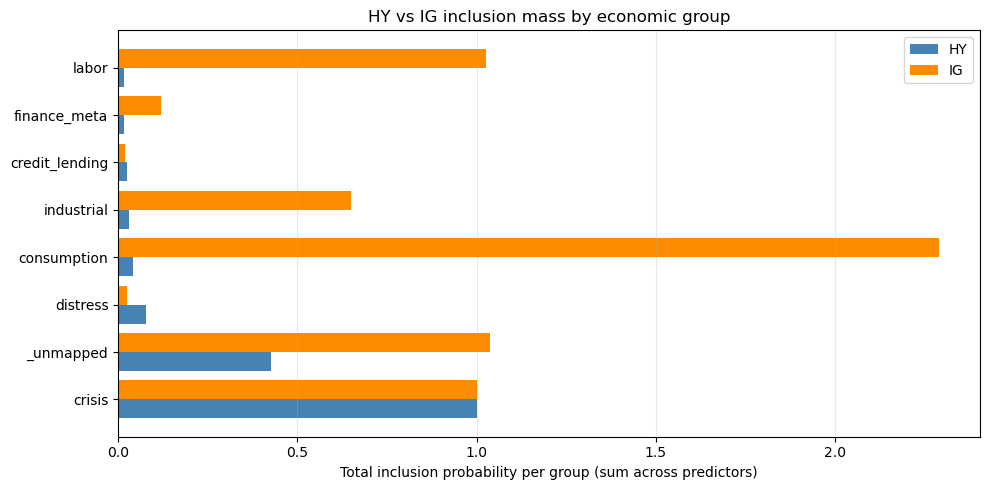

In [5]:
fig, ax = plt.subplots(figsize=(10, 5))
yy = np.arange(len(group_df))
bar_h = 0.4
ax.barh(yy - bar_h/2, group_df['HY_total_incl_prob'].values, height=bar_h, color='steelblue', label='HY')
ax.barh(yy + bar_h/2, group_df['IG_total_incl_prob'].values, height=bar_h, color='darkorange', label='IG')
ax.set_yticks(yy)
ax.set_yticklabels(group_df['group'])
ax.set_xlabel('Total inclusion probability per group (sum across predictors)')
ax.set_title('HY vs IG inclusion mass by economic group')
ax.legend()
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

## 3. Shared vs divergent predictors

A predictor counts as **shared** if it has inclusion prob ≥ 0.30 in BOTH HY and IG; **HY-only** / **IG-only** if it crosses the threshold for one target but not the other.

In [6]:
thresh = 0.30
shared = combined[(combined['HY'] >= thresh) & (combined['IG'] >= thresh)]
hy_only = combined[(combined['HY'] >= thresh) & (combined['IG'] < thresh)]
ig_only = combined[(combined['HY'] < thresh) & (combined['IG'] >= thresh)]
print(f'Shared (both >= {thresh}):  {len(shared)} predictors')
print(shared.round(3).to_string() if len(shared) else '  (none)')
print(f'\nHY-only (HY >= {thresh} & IG < {thresh}): {len(hy_only)}')
print(hy_only.round(3).to_string() if len(hy_only) else '  (none)')
print(f'\nIG-only (IG >= {thresh} & HY < {thresh}): {len(ig_only)}')
print(ig_only.round(3).to_string() if len(ig_only) else '  (none)')

Shared (both >= 0.3):  1 predictors
                  HY   IG
Economic crisis  1.0  1.0

HY-only (HY >= 0.3 & IG < 0.3): 1
        HY     IG
vix  0.408  0.022

IG-only (IG >= 0.3 & HY < 0.3): 5
                            HY     IG
Manufacturing            0.006  0.490
Recruitment & Staffing   0.003  0.975
ust10y                   0.002  1.000
Hotels & Accommodations  0.002  0.992
Travel                   0.001  0.992
